# Fintech Credit Risk Analysis
### Statistical Inference & Predictive Modeling

**Notebook:** 07_inference_and_prediction.ipynb  
**Phase:** 7 — Statistical Inference & Predictive Modeling  
**Input:** data/processed/cs_training_exposure_scored.csv  
**Author:** Taofeek Salami  
**Date:** 2026-08-27

**Methodology note:** Phases 2 and 3 established that default rates
differ substantially across `risk_tier` and `exposure_tier` using
observed percentages and cross-tabulation. This notebook extends
that work in two directions: first, formally testing whether the
`risk_tier` separation is statistically significant rather than
assuming it from the observed spread; second, building a predictive
model that estimates probability of default from the engineered
features already validated in Phases 2 and 3, rather than only
describing risk after the fact.

This notebook does not rebuild or replace the existing Tableau
dashboards — it is a standalone analytical extension referencing the
same dataset.

In [1]:
import pandas as pd
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from statsmodels.stats.proportion import confint_proportions_2indep
import statsmodels.api as sm
import matplotlib.pyplot as plt

## Data Load & Validation

Loads the Phase 3 output dataset (149,999 rows) and confirms
risk_tier and exposure_tier counts match the values validated in
Phase 2 and Phase 3 (e.g. risk_tier Critical = 5,356, exposure_tier
Critical = 6,603) before building any new analysis on top of it.

In [2]:
df = pd.read_csv('../data/processed/cs_training_exposure_scored.csv')
print(df.shape)
print(df['risk_tier'].value_counts())
print(df['exposure_tier'].value_counts())

(149999, 27)
risk_tier
Medium      66051
Low         60578
High        18014
Critical     5356
Name: count, dtype: int64
exposure_tier
Low                               63709
Moderate                          40394
Indeterminate (income missing)    29731
High                               9562
Critical                           6603
Name: count, dtype: int64


## Statistical Inference — Risk Tier Separation

Tests whether the default rate differences observed across risk_tier
in Phase 2 (Low 2.23% -> Critical 47.11%) reflect a genuine
relationship rather than sampling noise.

### Chi-Square Test (All Tiers)

Tests independence between risk_tier and SeriousDlqin2yrs across all
four tiers.

H0: risk_tier and default status are independent (tier carries no
real information about default risk)  
H1: risk_tier and default status are dependent

In [3]:
contingency = pd.crosstab(df['risk_tier'], df['SeriousDlqin2yrs'])
print(contingency)

chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f"\nChi-square statistic: {chi2:.2f}")
print(f"p-value: {p_value}")
print(f"Degrees of freedom: {dof}")

SeriousDlqin2yrs      0     1
risk_tier                    
Critical           2833  2523
High              14490  3524
Low               59225  1353
Medium            63425  2626

Chi-square statistic: 21521.39
p-value: 0.0
Degrees of freedom: 3


### Two-Proportion Z-Test (Low vs. Critical)

Tests whether the observed default rate gap between the Low and
Critical risk tiers (2.23% vs. 47.11%, Phase 2) reflects a real
difference rather than sampling variation, and quantifies that
difference with a 95% confidence interval.

H0: default rate is equal between Low and Critical risk tiers  
H1: default rate differs between Low and Critical risk tiers

In [4]:
low_defaults = contingency.loc['Low', 1]
low_total = contingency.loc['Low'].sum()

critical_defaults = contingency.loc['Critical', 1]
critical_total = contingency.loc['Critical'].sum()

z_stat, p_val = proportions_ztest(
    count=[low_defaults, critical_defaults],
    nobs=[low_total, critical_total]
)

ci_low, ci_high = confint_proportions_2indep(
    count1=critical_defaults, nobs1=critical_total,
    count2=low_defaults, nobs2=low_total
)

print(f"Low default rate: {low_defaults/low_total:.4f}")
print(f"Critical default rate: {critical_defaults/critical_total:.4f}")
print(f"Z-statistic: {z_stat:.2f}")
print(f"p-value: {p_val}")
print(f"95% CI for the difference (Critical - Low): ({ci_low:.4f}, {ci_high:.4f})")

Low default rate: 0.0223
Critical default rate: 0.4711
Z-statistic: -133.82
p-value: 0.0
95% CI for the difference (Critical - Low): (0.4353, 0.4622)


### Key Finding

Both tests confirm the risk_tier separation established in Phase 2
is statistically significant, not sampling noise:

- Chi-square test across all four tiers: χ² = 21521.39, df = 3,
  p < 0.001
- Two-proportion z-test, Low vs. Critical: z = -133.82, p < 0.001,
  95% CI for the difference in default rates: (43.5%, 46.2%)

## Predictive Modeling — Probability of Default

### Feature Preparation

Builds the feature matrix for logistic regression. risk_tier and
exposure_tier are one-hot encoded with Low as the reference category
for each, so each resulting coefficient is interpreted relative to a
Low-risk, Low-exposure borrower. income_missing is excluded: Phase 3
defines exposure_tier as "Indeterminate" exactly when income is
missing, so the two features are redundant and including both causes
the model to fail to estimate standard errors.
delinquency_data_error_flag is already binary. RevolvingUtilizationOf
UnsecuredLines and age are used as continuous features.

In [5]:
features = df[[
    'risk_tier', 'exposure_tier',
    'delinquency_data_error_flag',
    'RevolvingUtilizationOfUnsecuredLines', 'age'
]].copy()

features = pd.get_dummies(
    features,
    columns=['risk_tier', 'exposure_tier'],
    drop_first=False
)

# Drop the Low reference category manually for each, so it's explicit
# which category each block of dummies is relative to
features = features.drop(columns=['risk_tier_Low', 'exposure_tier_Low'])

target = df['SeriousDlqin2yrs']

print(features.columns.tolist())
print(features.shape)

['delinquency_data_error_flag', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'risk_tier_Critical', 'risk_tier_High', 'risk_tier_Medium', 'exposure_tier_Critical', 'exposure_tier_High', 'exposure_tier_Indeterminate (income missing)', 'exposure_tier_Moderate']
(149999, 10)


### Train/Test Split

80/20 stratified split, preserving the 6.68% default rate in both
sets. random_state is fixed for reproducibility.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    features, target,
    test_size=0.2,
    stratify=target,
    random_state=42
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Train default rate: {y_train.mean():.4f}")
print(f"Test default rate: {y_test.mean():.4f}")

Train shape: (119999, 10)
Test shape: (30000, 10)
Train default rate: 0.0668
Test default rate: 0.0668


### Logistic Regression — Coefficients & Significance

Fits with statsmodels first to obtain coefficient estimates, p-values,
and confidence intervals for each feature. Coefficient signs are
checked against the direction each feature is already known to move
in from Phase 2/3 (e.g. higher risk tier and higher exposure tier
should increase predicted default probability, not decrease it).

In [7]:
X_train_sm = sm.add_constant(X_train.astype(int))

logit_model = sm.Logit(y_train, X_train_sm)
result = logit_model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.192801
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:       SeriousDlqin2yrs   No. Observations:               119999
Model:                          Logit   Df Residuals:                   119988
Method:                           MLE   Df Model:                           10
Date:                Thu, 27 Aug 2026   Pseudo R-squ.:                  0.2143
Time:                        13:04:54   Log-Likelihood:                -23136.
converged:                       True   LL-Null:                       -29447.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
const                                   

### Coefficient Interpretation

All risk_tier and exposure_tier coefficients are positive and highly
significant (p < 0.001), with coefficient magnitude increasing with
tier severity — consistent with the default rates validated in
Phase 2 and Phase 3. age is negative and significant, consistent
with the Phase 2 finding that default risk decreases with age.

delinquency_data_error_flag and RevolvingUtilizationOfUnsecuredLines
are not significant in this model. Both are components already
absorbed into the tier variables: flagged borrowers were
automatically assigned to risk_tier Critical in Phase 2, and
utilization was one of two inputs to exposure_index in Phase 3. Their
predictive signal is already fully captured by the tiers rather than
lost.

Pseudo R-squared: 0.2143.

### Model Fit & Evaluation (scikit-learn)

Fits the same feature set using scikit-learn for prediction and
evaluation. class_weight='balanced' is used to account for the
6.68% positive class rate, so the model isn't biased toward simply
predicting "no default" for everyone.

In [8]:
clf = LogisticRegression(class_weight='balanced', max_iter=1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

auc = roc_auc_score(y_test, y_pred_proba)
gini = 2 * auc - 1
print(f"AUC: {auc:.4f}")
print(f"Gini: {gini:.4f}")

[[22348  5647]
 [  571  1434]]
              precision    recall  f1-score   support

           0       0.98      0.80      0.88     27995
           1       0.20      0.72      0.32      2005

    accuracy                           0.79     30000
   macro avg       0.59      0.76      0.60     30000
weighted avg       0.92      0.79      0.84     30000

AUC: 0.8349
Gini: 0.6699


### Evaluation

The model correctly identifies 72% of actual defaulters (recall),
at a precision of 20% — for every 5 borrowers flagged, roughly 1
defaults. This reflects the balanced class weighting, which
prioritizes catching defaulters over minimizing false alarms, a
reasonable tradeoff for a screening tool rather than a final
decision-maker.

AUC of 0.8349 (Gini 0.6699) exceeds the typical Gini range of
0.4-0.6 for a retail credit scorecard.

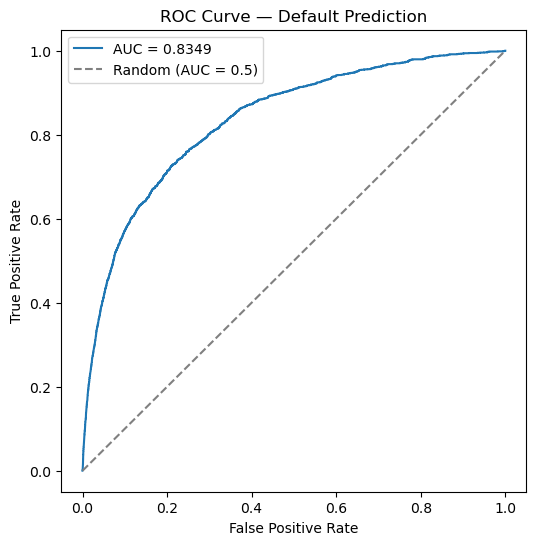

In [9]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Default Prediction')
plt.legend()
plt.savefig('../outputs/chart_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

### Business Interpretation

The model estimates probability of default (PD) using features
already validated in Phases 2 and 3. It correctly identifies 72% of
actual defaulters, at the cost of a high false-positive rate (20%
precision) — appropriate for a screening tool that flags borrowers
for manual underwriting review, not for automated approval/decline
decisions.

This model estimates PD only. A full Expected Loss figure
(EL = PD x LGD x EAD) is not computable from this dataset, since it
contains no loan balance, credit limit, or recovery data needed to
estimate Loss Given Default or Exposure at Default.

The risk_tier and exposure_tier variables built in Phases 2 and 3
carry nearly all of the model's predictive power — both the
statistical test results and the coefficient-significance pattern
confirm the underlying scoring methodology, rather than treating
that methodology as a separate, unvalidated assumption.